## Exercício de SVM 

**Fraude em Vinhos**
- A fraude em vinhos está relacionada aos aspectos comerciais do produto. O tipo mais comum de fraude envolve a adulteração de vinhos, geralmente pela adição de produtos mais baratos (como sucos) e, por vezes, de substâncias químicas nocivas e adoçantes (para corrigir a cor ou o sabor).
- O dataset possui dados de uma distribuidora de vinhos caros e de altíssima qualidade.
- Criar um modelo de aprendizado de máquina capaz de identificar amostras de vinho de baixa qualidade (ou seja, casos de "fraude"). O objetivo é verificar se é possível detectar essa diferença.

Data Source: *P. Cortez, A. Cerdeira, F. Almeida, T. Matos e J. Reis. Modeling wine preferences by data mining from physicochemical properties.
In Decision Support Systems, Elsevier, 47(4):547-553, 2009.*


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.svm import SVC, SVR, LinearSVR
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, accuracy_score, classification_report, confusion_matrix

In [3]:
df = pd.read_csv("./data/wine_fraud.csv")

In [4]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,Legit,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,Legit,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,Legit,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,Legit,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,Legit,red


In [5]:
df['quality'].unique()

array(['Legit', 'Fraud'], dtype=object)

<Axes: xlabel='quality', ylabel='count'>

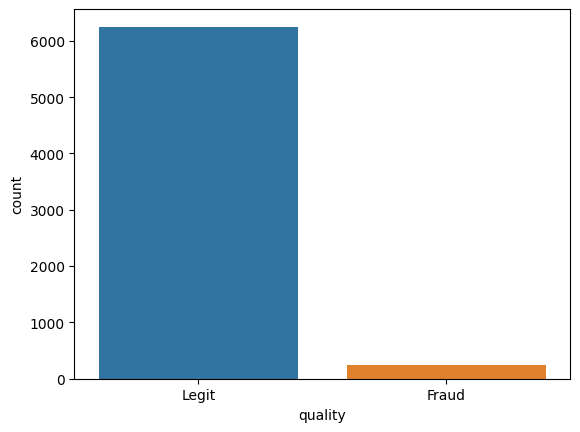

In [6]:
sns.countplot(x='quality', data=df, hue='quality', palette='tab10')

<Axes: xlabel='type', ylabel='count'>

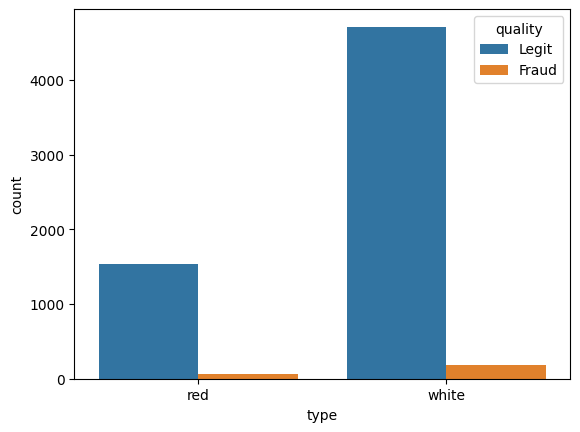

In [7]:
sns.countplot(x='type', data=df, hue='quality', palette='tab10')

In [8]:
fraud_percentage = (
    df.groupby('type')['quality']
      .apply(lambda x: (x == 'Fraud').mean() * 100)
)

In [9]:
print(f"Porcentagen de vinhos brancos fraudulentos: {fraud_percentage['white']:.2f}%")

Porcentagen de vinhos brancos fraudulentos: 3.74%


In [10]:
print(f"Porcentagem de vinhos tintos fraudulentos: {fraud_percentage['red']:.2f}%")

Porcentagem de vinhos tintos fraudulentos: 3.94%


In [11]:
df['Fraud'] = df['quality'].apply(lambda x: 1 if x == 'Fraud' else 0)

In [36]:
corr_fraud = df.select_dtypes(include=[np.number]).corrwith(df['Fraud'])
corr_fraud = corr_fraud.drop('Fraud').sort_values(ascending=True)
print(corr_fraud)

free sulfur dioxide    -0.085204
citric acid            -0.061789
alcohol                -0.051141
residual sugar         -0.048756
total sulfur dioxide   -0.035252
sulphates              -0.034046
density                 0.016351
pH                      0.020107
fixed acidity           0.021794
chlorides               0.034499
volatile acidity        0.151228
dtype: float64


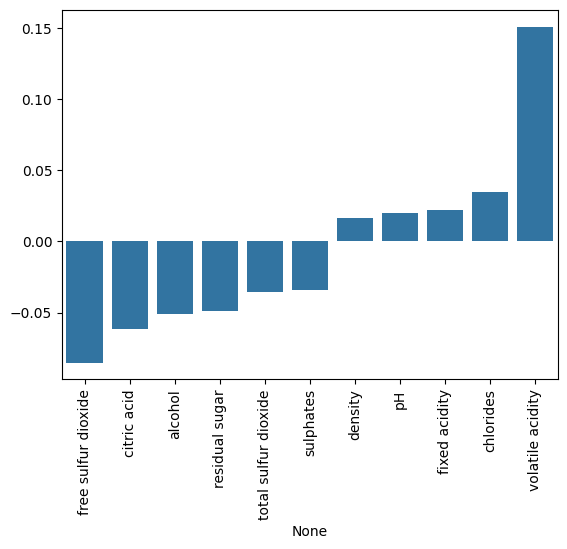

In [39]:
sns.barplot(
    x=corr_fraud.index, 
    y=corr_fraud.values
)
plt.xticks(rotation=90)
plt.show()

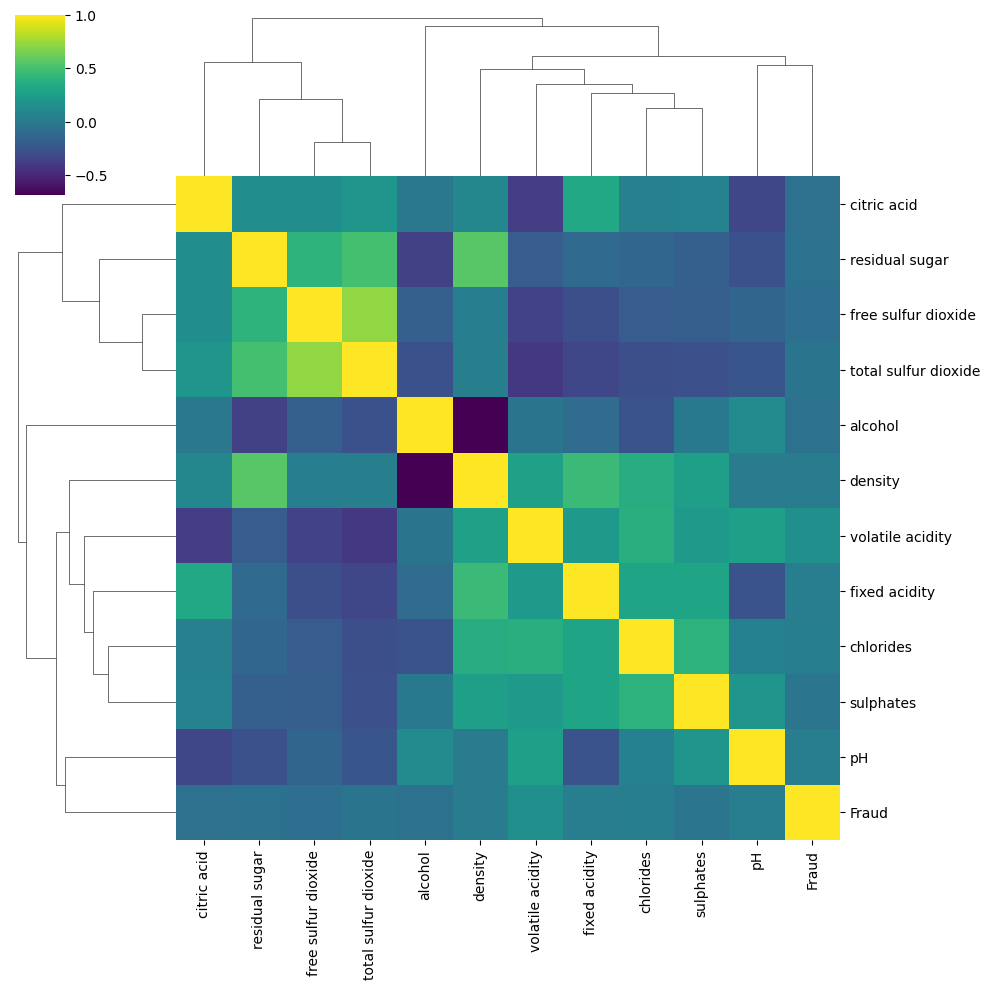

In [67]:
sns.clustermap(
    df.corr(numeric_only=True),
    cmap='viridis',
    annot=False
)

In [71]:
df['type'] = pd.get_dummies(df['type'],drop_first=True)
df = df.drop('Fraud',axis=1)

In [72]:
X = df.drop('quality', axis=1)
y = df['quality']

In [73]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=101)

In [74]:
scaler = StandardScaler()

In [77]:
scaled_X_train = scaler.fit_transform(X_train)
scaled_X_test = scaler.transform(X_test)

In [79]:
svc = SVC(class_weight='balanced')

In [80]:
param_grid = {'C':[0.001,0.01,0.1,0.5,1],'gamma':['scale','auto']}
grid = GridSearchCV(svc,param_grid)
grid.fit(scaled_X_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC(class_weight='balanced')
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.001, 0.01, ...], 'gamma': ['scale', 'auto']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : t

In [82]:
grid.best_params_

{'C': 1, 'gamma': 'auto'}

In [83]:
grid_pred = grid.predict(scaled_X_test)

In [85]:
confusion_matrix(y_test,grid_pred)

array([[ 17,  10],
       [ 92, 531]])

In [88]:
print(classification_report(y_test,grid_pred))

              precision    recall  f1-score   support

       Fraud       0.16      0.63      0.25        27
       Legit       0.98      0.85      0.91       623

    accuracy                           0.84       650
   macro avg       0.57      0.74      0.58       650
weighted avg       0.95      0.84      0.88       650



## Decisão
- O modelo apresenta uma **accuracy** relativamente alta, porém esse resultado é influenciado pelo *forte desbalanceamento das classes*. Como a maioria dos exemplos pertence à classe Legit, o modelo consegue obter muitos acertos nessa classe. Entretanto, seu desempenho na detecção de fraudes é insatisfatório, principalmente devido ao **baixo precision de 16%**. Além disso, das 27 fraudes presentes no conjunto de teste, 10 foram classificadas como legítimas, representando falsos negativos. Em um cenário de detecção de fraude, esses erros são especialmente preocupantes, pois significam fraudes que passam despercebidas pelo sistema.
- Não é necessariamente que o modelo esteja *"inadequado"* só porque o dataset é desbalanceado. O desbalanceamento é uma característica do problema, e existem técnicas para lidar com ele.
  - O class_weight='balanced' e o threshold são mecanismos para lidar com o problema.
  
**Será que o SVC é o modelo certo para esse problema?**
- Nesse cenário seria interessante testar outro modelos e compará-los. 
  - Nesse caso modelos como, Logistic Regression, Random Forest, Gradient Boosting, XGBoost,também poderiam ser avaliados e testados.

**O problema não é simplesmente o modelo**
  - A análise química não é necessariamente insuficiente para prever fraude. O problema é que ela não contém uma informação direta de “fraude”. Um modelo pode aprender padrões estatísticos entre essas características e o rótulo Fraud, mas isso não significa que a composição química, sozinha, consiga identificar toda fraude.
  - Seria interessante ter informações adicionais que poderiam melhorar a detecção como, Rótulo, Local de Compra, Historico do estabelecimento, Preço, Região, Lote e etc.